# Pertemuan 05 — Hands-on 06: Dari Klasifikasi ke Deteksi & Segmentasi
**Mata Kuliah:** Deep Learning (IF25-40401) — Program Studi Teknik Informatika, Institut Teknologi Sumatera (ITERA)
**Materi:** Format Bounding Box (Pascal VOC, COCO, YOLO), IoU, Non-Maximum Suppression, Precision–Recall & mAP, Target Grid YOLO, Deteksi & Segmentasi Pretrained, Mini U-Net
**Alokasi Waktu:** ~55 Menit (Tatap Muka Kelas TM 3×50′)
**Slide Terkait:** Pertemuan 5, Bagian 06 (Slide 43–52)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/informatika-itera/deep-learning-IF25-40401/blob/main/materials/notebooks/06-bbox-iou-nms-deteksi-segmentasi.ipynb)

---

### Capaian Pembelajaran (Sub-CPMK)
1. **Sub-CPMK 6:** Mengonversi bounding box antar format Pascal VOC, COCO, dan YOLO, serta mengenali jebakan umum saat membaca anotasi.
2. **Sub-CPMK 6:** Mengimplementasikan IoU, NMS, dan mAP dari nol lalu memverifikasinya terhadap `torchvision.ops`.
3. **Sub-CPMK 6:** Memahami bentuk output detektor (grid YOLO, Faster R-CNN) dan segmentasi (DeepLabV3, U-Net) sebagai perluasan backbone CNN.

---

### Konfigurasi Mode Eksekusi
- `MODE_CEPAT = True` melatih mini U-Net selama 300 langkah (±1 menit di CPU).
- `UNDUH_PRETRAINED = True` mengunduh Faster R-CNN MobileNetV3 (~74 MB), DeepLabV3 MobileNetV3 (~42 MB), dan satu citra COCO. Setel ke `False` bila koneksi terbatas; bagian lain berjalan **luring**.

In [1]:
# Saklar Kecepatan Eksekusi untuk Live-Coding di Kelas
MODE_CEPAT = True         # True: mini U-Net 300 langkah | False: 1.500 langkah
UNDUH_PRETRAINED = True   # False: lewati Bagian 8 (tanpa unduhan bobot)

import os
import json
import time
import urllib.request
import xml.etree.ElementTree as ET
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import matplotlib.cbook as cbook
from matplotlib import font_manager

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import models
from torchvision.ops import box_convert, box_iou, nms
from torchvision.utils import draw_bounding_boxes, draw_segmentation_masks
import torchvision.transforms.functional as TF

np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))
TEAL, BLUE, ORANGE, INK, MUTE, RED = '#0A7281', '#1151FF', '#DE8F05', '#111111', '#707072', '#C0392B'

print("=" * 65)
print(f"PyTorch / Torchvision : {torch.__version__} / {torchvision.__version__}")
print(f"Perangkat Komputasi   : {device}")
print("=" * 65)

PyTorch / Torchvision : 2.14.0 / 0.29.0
Perangkat Komputasi   : mps


## 1. Tiga Konvensi Penulisan Bounding Box (Slide 44–45)

| Format | Isi vektor | Satuan | Berkas anotasi |
|:--|:--|:--|:--|
| **Pascal VOC** | $[x_{\min}, y_{\min}, x_{\max}, y_{\max}]$ | piksel | 1 XML per citra |
| **COCO** | $[x_{\min}, y_{\min}, w, h]$ | piksel | 1 JSON per split |
| **YOLO** | $[c, \; x_c/W, \; y_c/H, \; w/W, \; h/H]$ | relatif $[0, 1]$ | 1 `.txt` per citra |

Ketiganya memakai titik asal $(0,0)$ di **kiri-atas** citra dengan sumbu $y$ mengarah ke bawah. Kita tulis empat fungsi konversi (semuanya lewat format VOC sebagai "format pusat") dan uji dengan contoh slide 45: citra $640\times480$, box VOC $(64, 96, 320, 384)$.

In [2]:
def voc_ke_coco(b):
    x1, y1, x2, y2 = b.unbind(-1)
    return torch.stack([x1, y1, x2 - x1, y2 - y1], dim=-1)

def coco_ke_voc(b):
    x, y, w, h = b.unbind(-1)
    return torch.stack([x, y, x + w, y + h], dim=-1)

def voc_ke_yolo(b, W, H):
    x1, y1, x2, y2 = b.unbind(-1)
    return torch.stack([(x1 + x2) / (2 * W), (y1 + y2) / (2 * H), (x2 - x1) / W, (y2 - y1) / H], dim=-1)

def yolo_ke_voc(b, W, H):
    xc, yc, w, h = b.unbind(-1)
    return torch.stack([(xc - w / 2) * W, (yc - h / 2) * H, (xc + w / 2) * W, (yc + h / 2) * H], dim=-1)


W_IMG, H_IMG = 640, 480
voc = torch.tensor([[64., 96., 320., 384.]])
coco = voc_ke_coco(voc)
yolo = voc_ke_yolo(voc, W_IMG, H_IMG)

print(f"Pascal VOC : {voc.tolist()[0]}")
print(f"COCO       : {coco.tolist()[0]}")
print(f"YOLO       : 0 {' '.join(f'{v:.3f}' for v in yolo.tolist()[0])}   (baris di berkas .txt, kelas 0)")

# Verifikasi terhadap torchvision.ops.box_convert
assert torch.allclose(coco, box_convert(voc, 'xyxy', 'xywh'))
assert torch.allclose(yolo, box_convert(voc, 'xyxy', 'cxcywh') / torch.tensor([W_IMG, H_IMG, W_IMG, H_IMG]))
# Uji bolak-balik (round trip)
assert torch.allclose(coco_ke_voc(coco), voc) and torch.allclose(yolo_ke_voc(yolo, W_IMG, H_IMG), voc)
print("\n✓ Cocok dengan box_convert dan lolos uji bolak-balik")

Pascal VOC : [64.0, 96.0, 320.0, 384.0]
COCO       : [64.0, 96.0, 256.0, 288.0]
YOLO       : 0 0.300 0.500 0.400 0.600   (baris di berkas .txt, kelas 0)

✓ Cocok dengan box_convert dan lolos uji bolak-balik


### 1b. Jebakan: Salah Membaca Format

Apa yang terjadi bila vektor COCO `[64, 96, 256, 288]` dibaca sebagai `xyxy`? Model bisa saja memprediksi dengan sempurna, tetapi evaluasi akan mengatakan IoU-nya hanya 0,5.

IoU box asli vs box salah baca: 0.500


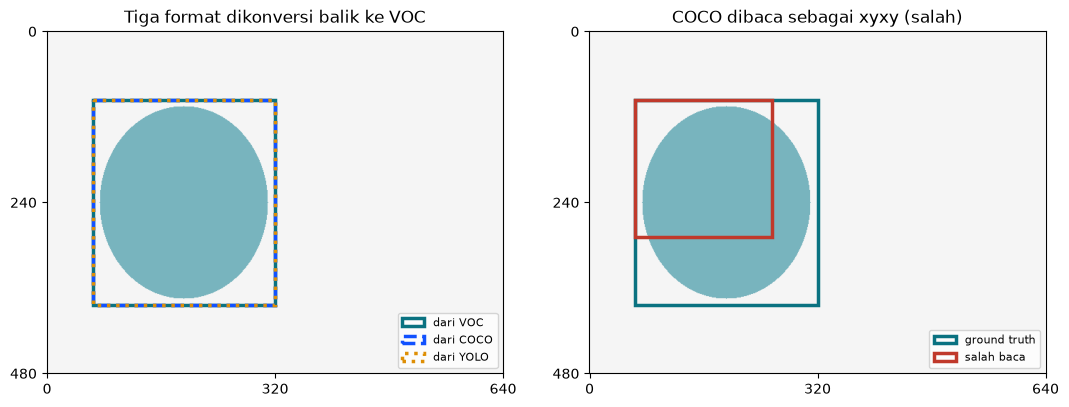

In [3]:
salah_baca = coco.clone()   # [64, 96, 256, 288] diperlakukan seolah (x1, y1, x2, y2)
print(f"IoU box asli vs box salah baca: {box_iou(voc, salah_baca).item():.3f}")

# Gambar citra sintetis 640x480 dengan satu "objek"
citra = np.full((H_IMG, W_IMG, 3), 245, dtype=np.uint8)
yy, xx = np.mgrid[:H_IMG, :W_IMG]
citra[((xx - 192) / 118) ** 2 + ((yy - 240) / 135) ** 2 <= 1] = (120, 180, 190)

fig, axs = plt.subplots(1, 2, figsize=(11, 4))
for ax, judul in zip(axs, ['Tiga format dikonversi balik ke VOC', 'COCO dibaca sebagai xyxy (salah)']):
    ax.imshow(citra)
    ax.set_title(judul)
    ax.set_xticks([0, 320, 640]); ax.set_yticks([0, 240, 480])
for b, warna, ls, lbl in [(voc[0], TEAL, '-', 'dari VOC'), (coco_ke_voc(coco)[0], BLUE, '--', 'dari COCO'),
                          (yolo_ke_voc(yolo, W_IMG, H_IMG)[0], ORANGE, ':', 'dari YOLO')]:
    x1, y1, x2, y2 = b.tolist()
    axs[0].add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, lw=2.5, ec=warna, ls=ls, label=lbl))
axs[0].legend(loc='lower right', fontsize=8)
for b, warna, lbl in [(voc[0], TEAL, 'ground truth'), (salah_baca[0], RED, 'salah baca')]:
    x1, y1, x2, y2 = b.tolist()
    axs[1].add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, lw=2.5, ec=warna, label=lbl))
axs[1].legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

## 2. Membaca Berkas Anotasi Asli (Slide 46)

Isi ketiga berkas di bawah disalin dari slide 46. Kita *parse* masing-masing (XML dengan `xml.etree`, JSON dengan `json`, teks biasa dengan `split`) lalu pastikan hasilnya box yang sama.

In [4]:
anotasi_voc = """<annotation>
  <size><width>640</width><height>480</height></size>
  <object>
    <name>cat</name>
    <bndbox>
      <xmin>64</xmin>  <ymin>96</ymin>
      <xmax>320</xmax> <ymax>384</ymax>
    </bndbox>
  </object>
</annotation>"""

anotasi_coco = """{"images": [{"id": 1, "file_name": "img001.jpg", "width": 640, "height": 480}],
 "annotations": [{"id": 1, "image_id": 1, "category_id": 17, "iscrowd": 0,
                  "bbox": [64, 96, 256, 288]}],
 "categories": [{"id": 17, "name": "cat"}]}"""

anotasi_yolo = "0 0.300 0.500 0.400 0.600"

# Pascal VOC (XML)
root = ET.fromstring(anotasi_voc)
bb = root.find('object/bndbox')
box_dari_voc = torch.tensor([[float(bb.find(k).text) for k in ('xmin', 'ymin', 'xmax', 'ymax')]])

# COCO (JSON)
data_coco = json.loads(anotasi_coco)
info = data_coco['images'][0]
box_dari_coco = coco_ke_voc(torch.tensor([data_coco['annotations'][0]['bbox']], dtype=torch.float))

# YOLO (.txt): butuh ukuran citra dari sumber lain (mis. membuka berkas citranya)
kelas, *nilai = anotasi_yolo.split()
box_dari_yolo = yolo_ke_voc(torch.tensor([[float(v) for v in nilai]]), info['width'], info['height'])

for nama, b in [('VOC', box_dari_voc), ('COCO', box_dari_coco), ('YOLO', box_dari_yolo)]:
    print(f"{nama:<5} -> xyxy {[round(v, 1) for v in b.tolist()[0]]}")
assert torch.allclose(box_dari_voc, box_dari_coco) and torch.allclose(box_dari_voc, box_dari_yolo, atol=1e-3)
print(f"\nNama kelas: VOC '{root.find('object/name').text}' | COCO category_id {data_coco['annotations'][0]['category_id']} "
      f"('{data_coco['categories'][0]['name']}') | YOLO indeks {kelas}")

VOC   -> xyxy [64.0, 96.0, 320.0, 384.0]
COCO  -> xyxy [64.0, 96.0, 320.0, 384.0]
YOLO  -> xyxy [64.0, 96.0, 320.0, 384.0]

Nama kelas: VOC 'cat' | COCO category_id 17 ('cat') | YOLO indeks 0


## 3. Jebakan: *Resize* Citra (Slide 45)

Model deteksi biasanya menerima citra berukuran tetap. Bila citra $640\times480$ di-*resize* menjadi $320\times320$:
- Label **VOC/COCO** (piksel) **harus diskalakan** dengan faktor $s_x = 320/640$ dan $s_y = 320/480$.
- Label **YOLO** (relatif) **tidak berubah**, karena posisi relatif objek terhadap citra tetap sama.

VOC diskalakan        : [32.0, 64.0, 160.0, 256.0]
YOLO (tidak berubah) -> [32.0, 64.0, 160.0, 256.0]
VOC lupa diskalakan   : [64.0, 96.0, 320.0, 384.0]  -> IoU dengan box benar 0.185


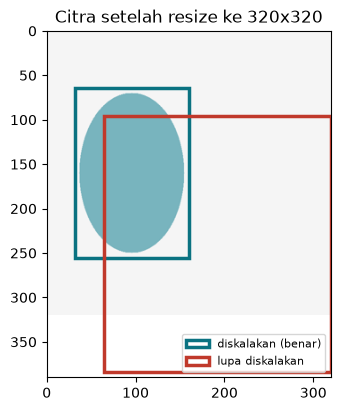

In [5]:
W_BARU, H_BARU = 320, 320
citra_resize = np.array(Image.fromarray(citra).resize((W_BARU, H_BARU)))
skala = torch.tensor([W_BARU / W_IMG, H_BARU / H_IMG, W_BARU / W_IMG, H_BARU / H_IMG])

voc_diskalakan = voc * skala
voc_dari_yolo = yolo_ke_voc(yolo, W_BARU, H_BARU)          # label YOLO dipakai apa adanya
print(f"VOC diskalakan        : {voc_diskalakan.tolist()[0]}")
print(f"YOLO (tidak berubah) -> {[round(v, 1) for v in voc_dari_yolo.tolist()[0]]}")
print(f"VOC lupa diskalakan   : {voc.tolist()[0]}  -> IoU dengan box benar {box_iou(voc, voc_diskalakan).item():.3f}")

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.imshow(citra_resize)
for b, warna, lbl in [(voc_diskalakan[0], TEAL, 'diskalakan (benar)'), (voc[0], RED, 'lupa diskalakan')]:
    x1, y1, x2, y2 = b.tolist()
    ax.add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, lw=2.5, ec=warna, label=lbl))
ax.set_xlim(0, W_BARU); ax.set_ylim(H_BARU + 70, 0)
ax.legend(loc='lower right', fontsize=8)
ax.set_title('Citra setelah resize ke 320x320')
plt.show()

## 4. Intersection over Union dari Nol (Slide 47)

$$\text{IoU}(A, B) = \frac{|A \cap B|}{|A \cup B|}$$

Implementasi di bawah **tervektorisasi**: menghitung IoU antara $N$ box dan $M$ box sekaligus (matriks $N\times M$) memakai *broadcasting*, tanpa loop Python. Box dalam format `xyxy`.

In [6]:
def iou_matriks(a, b):
    """IoU antara setiap box di a (N, 4) dan setiap box di b (M, 4), format xyxy -> (N, M)."""
    kiri_atas = torch.max(a[:, None, :2], b[None, :, :2])      # (N, M, 2)
    kanan_bawah = torch.min(a[:, None, 2:], b[None, :, 2:])    # (N, M, 2)
    wh = (kanan_bawah - kiri_atas).clamp(min=0)                # 0 bila tidak beririsan
    irisan = wh[..., 0] * wh[..., 1]
    luas_a = (a[:, 2] - a[:, 0]) * (a[:, 3] - a[:, 1])
    luas_b = (b[:, 2] - b[:, 0]) * (b[:, 3] - b[:, 1])
    return irisan / (luas_a[:, None] + luas_b[None, :] - irisan)


# Contoh slide 47: A = (1,1,5,5), B = (2,2,6,6)
A = torch.tensor([[1., 1., 5., 5.]])
B = torch.tensor([[2., 2., 6., 6.]])
print(f"IoU contoh slide: {iou_matriks(A, B).item():.4f}  (9/23 = {9/23:.4f})")

# Verifikasi pada 1.000 x 1.000 box acak
xy = torch.rand(1000, 2) * 500
wh = torch.rand(1000, 2) * 100 + 1
acak = torch.cat([xy, xy + wh], dim=1)
print(f"Selisih maks vs torchvision.ops.box_iou: {(iou_matriks(acak, acak.flip(0)) - box_iou(acak, acak.flip(0))).abs().max():.2e}")

IoU contoh slide: 0.3913  (9/23 = 0.3913)
Selisih maks vs torchvision.ops.box_iou: 0.00e+00


### 4b. Seberapa Sensitif IoU terhadap Pergeseran?

Geser sebuah box berukuran $100\times100$ secara horizontal dan amati IoU-nya. Pergeseran yang tampak kecil sudah cukup membuat deteksi dihitung **salah** pada ambang 0,5, apalagi pada ambang ketat COCO (hingga 0,95).

IoU >= 0,5 hanya bertahan sampai pergeseran 33 piksel (33% lebar box)


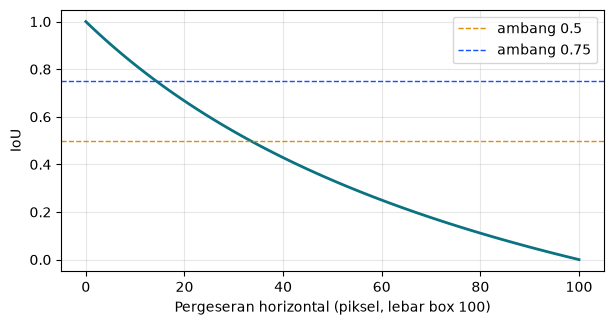

In [7]:
gt = torch.tensor([[100., 100., 200., 200.]])
geser = torch.arange(0, 101, 1.0)
pred_geser = gt.repeat(len(geser), 1) + torch.stack([geser, torch.zeros_like(geser), geser, torch.zeros_like(geser)], 1)
iou_geser = iou_matriks(gt, pred_geser)[0]

batas = geser[iou_geser >= 0.5].max().item()
print(f"IoU >= 0,5 hanya bertahan sampai pergeseran {batas:.0f} piksel ({batas:.0f}% lebar box)")

plt.figure(figsize=(7, 3.4))
plt.plot(geser, iou_geser, color=TEAL, lw=2)
for ambang, warna in [(0.5, ORANGE), (0.75, BLUE)]:
    plt.axhline(ambang, color=warna, ls='--', lw=1, label=f'ambang {ambang}')
plt.xlabel('Pergeseran horizontal (piksel, lebar box 100)')
plt.ylabel('IoU')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 5. Non-Maximum Suppression dari Nol (Slide 48)

Detektor menghasilkan banyak box yang tumpang tindih untuk satu objek. Algoritma NMS (per kelas):
1. Urutkan box berdasarkan skor.
2. Ambil box dengan skor tertinggi dan simpan.
3. Buang box lain yang IoU-nya dengan box tersebut **> ambang**.
4. Ulangi sampai tidak ada box tersisa.

Jumlah kandidat: 18 -> setelah NMS: 3
Indeks versi kita       : [17, 4, 6]
Indeks torchvision.nms  : [17, 4, 6]


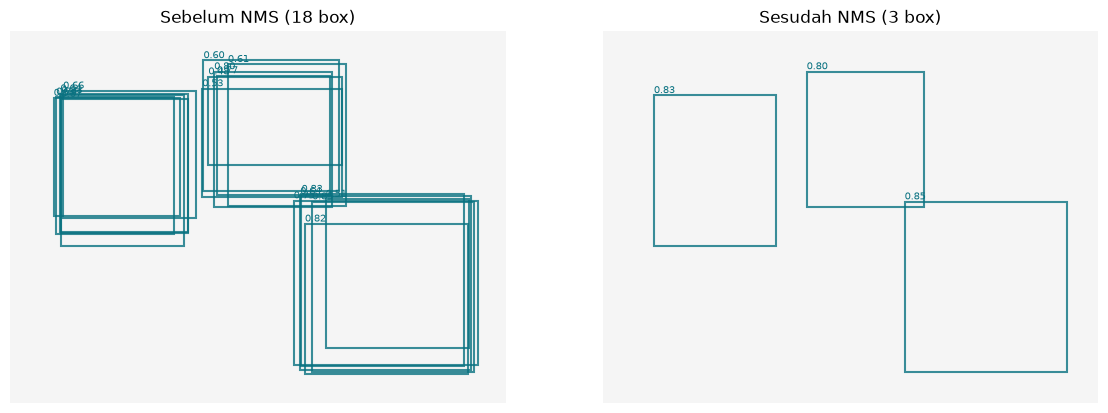

In [8]:
def nms_manual(boxes, scores, ambang=0.5):
    urutan = scores.argsort(descending=True)
    simpan = []
    while urutan.numel() > 0:
        terbaik = urutan[0]
        simpan.append(terbaik.item())
        sisa = urutan[1:]
        if sisa.numel() == 0:
            break
        iou = iou_matriks(boxes[terbaik].unsqueeze(0), boxes[sisa])[0]
        urutan = sisa[iou <= ambang]          # buang yang terlalu tumpang tindih
    return torch.tensor(simpan)


# Tiga objek, masing-masing "dideteksi" 6 kali dengan box bergeser acak
torch.manual_seed(3)
objek = torch.tensor([[60., 80., 220., 260.], [260., 60., 420., 200.], [380., 220., 600., 440.]])
kandidat, skor = [], []
for b in objek:
    kandidat.append(b + torch.randn(6, 4) * 12)
    skor.append(torch.rand(6) * 0.5 + 0.45)
kandidat, skor = torch.cat(kandidat), torch.cat(skor)

keep_kita = nms_manual(kandidat, skor, 0.5)
keep_tv = nms(kandidat, skor, 0.5)
print(f"Jumlah kandidat: {len(kandidat)} -> setelah NMS: {len(keep_kita)}")
print(f"Indeks versi kita       : {keep_kita.tolist()}")
print(f"Indeks torchvision.nms  : {keep_tv.tolist()}")
assert torch.equal(keep_kita, keep_tv)

fig, axs = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, idx, judul in [(axs[0], range(len(kandidat)), f'Sebelum NMS ({len(kandidat)} box)'), (axs[1], keep_kita.tolist(), f'Sesudah NMS ({len(keep_kita)} box)')]:
    ax.imshow(np.full((480, 640, 3), 245, dtype=np.uint8))
    for i in idx:
        x1, y1, x2, y2 = kandidat[i].tolist()
        ax.add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, lw=1.5, ec=TEAL, alpha=0.8))
        ax.text(x1, y1 - 3, f'{skor[i]:.2f}', color=TEAL, fontsize=7)
    ax.set_title(judul)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 6. Precision, Recall, AP, dan mAP (Slide 48)

Untuk satu kelas, semua prediksi dari **seluruh citra** diurutkan berdasarkan skor. Setiap prediksi dicocokkan dengan ground truth yang belum terpakai:
- **TP** bila IoU ≥ ambang dengan ground truth yang belum dipasangkan; selain itu **FP**.
- Menyusuri daftar dari skor tertinggi menghasilkan pasangan (precision, recall) kumulatif, yaitu **kurva PR**.
- **AP** = luas di bawah kurva PR (setelah precision dibuat monoton turun, *all-point interpolation*).
- **mAP** = rata-rata AP seluruh kelas. COCO juga merata-ratakan pada 10 ambang IoU: **mAP@[.5:.95]**.

Kita buat dataset sintetis: 30 citra, 2 kelas, prediksi berupa ground truth yang digeser acak ditambah beberapa *false positive*.

In [9]:
rng = np.random.default_rng(7)
KELAS = ['kucing', 'anjing']
gt_data, pred_data = [], []           # gt: (img, kelas, box) | pred: (img, kelas, box, skor)

for img in range(30):
    for _ in range(rng.integers(1, 4)):
        k = int(rng.integers(0, 2))
        x, y = rng.uniform(0, 400, 2)
        w, h = rng.uniform(60, 200, 2)
        box = np.array([x, y, x + w, y + h])
        gt_data.append((img, k, box))
        if rng.random() < 0.9:                            # 90% objek terdeteksi
            derau = rng.uniform(0.02, 0.25)               # kualitas lokalisasi bervariasi
            pred = box + rng.normal(0, derau, 4) * np.array([w, h, w, h])
            skor_pred = float(np.clip(1 - derau * 2.5 + rng.normal(0, 0.1), 0.05, 0.99))
            pred_data.append((img, k, pred, skor_pred))
    for _ in range(rng.integers(0, 2)):                   # false positive acak
        x, y = rng.uniform(0, 450, 2)
        pred_data.append((img, int(rng.integers(0, 2)), np.array([x, y, x + 80, y + 80]), float(rng.uniform(0.05, 0.6))))

print(f"Ground truth: {len(gt_data)} box | Prediksi: {len(pred_data)} box")


def hitung_ap(kelas, ambang_iou):
    gt_k = [(img, torch.tensor(b, dtype=torch.float)) for img, k, b in gt_data if k == kelas]
    pred_k = sorted([(img, torch.tensor(b, dtype=torch.float), s) for img, k, b, s in pred_data if k == kelas], key=lambda p: -p[2])
    terpakai = set()
    tp = []
    for img, box, _ in pred_k:
        kandidat = [(i, iou_matriks(box[None], g[None]).item()) for i, (gi, g) in enumerate(gt_k) if gi == img and i not in terpakai]
        i_terbaik, iou_terbaik = max(kandidat, key=lambda c: c[1], default=(None, 0.0))
        if iou_terbaik >= ambang_iou:
            terpakai.add(i_terbaik)
            tp.append(1)
        else:
            tp.append(0)
    tp = np.array(tp)
    tp_kum, fp_kum = np.cumsum(tp), np.cumsum(1 - tp)
    recall = tp_kum / len(gt_k)
    precision = tp_kum / (tp_kum + fp_kum)
    # all-point interpolation: precision dibuat monoton turun dari kanan
    r = np.concatenate([[0], recall, [recall[-1]]])
    p = np.concatenate([[1], precision, [0]])
    for i in range(len(p) - 2, -1, -1):
        p[i] = max(p[i], p[i + 1])
    ap = np.sum((r[1:] - r[:-1]) * p[1:])
    return ap, recall, precision


print(f"\n{'Kelas':<8}{'AP@0.5':>8}{'AP@0.75':>9}")
for k, nama in enumerate(KELAS):
    print(f"{nama:<8}{hitung_ap(k, 0.5)[0]:>8.3f}{hitung_ap(k, 0.75)[0]:>9.3f}")

ambang_coco = np.arange(0.5, 0.96, 0.05)
map_per_ambang = [np.mean([hitung_ap(k, t)[0] for k in range(len(KELAS))]) for t in ambang_coco]
print(f"\nmAP@0.5       (PASCAL VOC): {map_per_ambang[0]:.3f}")
print(f"mAP@[.5:.95]  (COCO)      : {np.mean(map_per_ambang):.3f}")

Ground truth: 58 box | Prediksi: 70 box

Kelas     AP@0.5  AP@0.75


kucing     0.647    0.258
anjing     0.764    0.250



mAP@0.5       (PASCAL VOC): 0.705
mAP@[.5:.95]  (COCO)      : 0.315


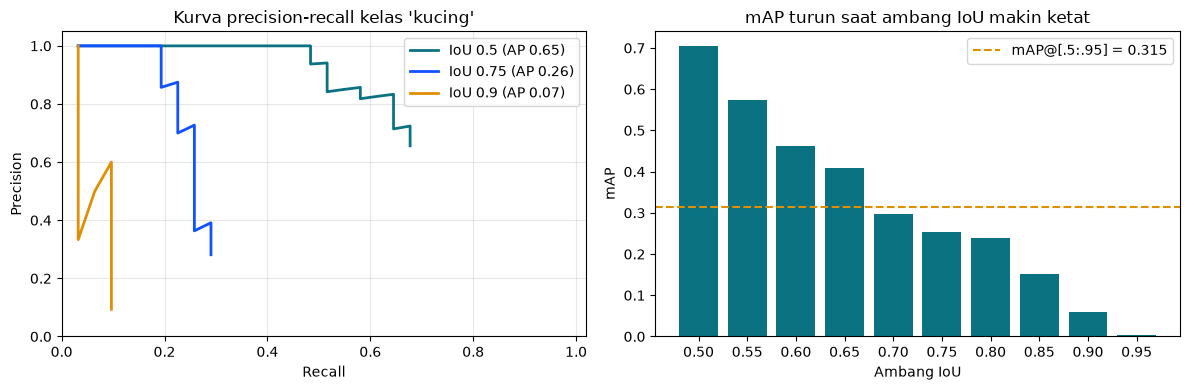

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
for ambang, warna in [(0.5, TEAL), (0.75, BLUE), (0.9, ORANGE)]:
    ap, rec, prec = hitung_ap(0, ambang)
    axs[0].plot(rec, prec, color=warna, lw=2, label=f'IoU {ambang} (AP {ap:.2f})')
axs[0].set_xlabel('Recall'); axs[0].set_ylabel('Precision')
axs[0].set_title(f"Kurva precision-recall kelas '{KELAS[0]}'")
axs[0].set_xlim(0, 1.02); axs[0].set_ylim(0, 1.05)
axs[0].legend(); axs[0].grid(alpha=0.3)

axs[1].bar([f'{t:.2f}' for t in ambang_coco], map_per_ambang, color=TEAL)
axs[1].axhline(np.mean(map_per_ambang), color=ORANGE, ls='--', label=f'mAP@[.5:.95] = {np.mean(map_per_ambang):.3f}')
axs[1].set_xlabel('Ambang IoU'); axs[1].set_ylabel('mAP')
axs[1].set_title('mAP turun saat ambang IoU makin ketat')
axs[1].legend()
plt.tight_layout()
plt.show()

Metrik COCO (mAP@[.5:.95]) jauh lebih ketat karena ikut menghukum **lokalisasi yang kurang presisi**, bukan hanya deteksi yang salah objek.

---

## 7. Target Grid YOLO: $S\times S\times(5B+C)$ (Slide 50)

YOLOv1 membagi citra $448\times448$ menjadi grid $S\times S = 7\times7$. **Sel yang memuat pusat objek** bertanggung jawab memprediksinya. Setiap sel memprediksi $B = 2$ box $(x, y, w, h, \text{conf})$ dan $C = 20$ probabilitas kelas (PASCAL VOC), sehingga output berukuran $7\times7\times30$.

Kita bangun tensor **target** untuk dua objek, lalu *decode* kembali. Perhatikan: $(x, y)$ relatif terhadap **sel**, sedangkan $(w, h)$ relatif terhadap **citra**, persis format YOLO dari Bagian 1.

Shape tensor target: (7, 7, 30)  (S x S x (5B + C) = 7 x 7 x 30)
  sel (baris 2, kolom 5) -> kelas 11, box [230.0, 60.0, 420.0, 300.0]
  sel (baris 4, kolom 2) -> kelas 7, box [40.0, 180.0, 250.0, 400.0]
Sel yang berisi objek: 2 dari 49


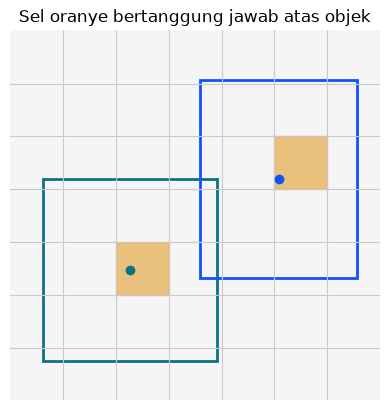

In [11]:
S, B_BOX, C_KELAS, UKURAN = 7, 2, 20, 448

objek_yolo = [  # (kelas VOC, box xyxy piksel)
    (7, torch.tensor([40., 180., 250., 400.])),    # 7 = cat
    (11, torch.tensor([230., 60., 420., 300.])),   # 11 = dog
]


def encode_target(daftar_objek):
    target = torch.zeros(S, S, 5 * B_BOX + C_KELAS)
    for kelas, box in daftar_objek:
        xc, yc, w, h = voc_ke_yolo(box, UKURAN, UKURAN).tolist()
        kolom, baris = int(xc * S), int(yc * S)             # sel yang memuat pusat objek
        x_sel, y_sel = xc * S - kolom, yc * S - baris       # offset di dalam sel, [0, 1)
        target[baris, kolom, 0:5] = torch.tensor([x_sel, y_sel, w, h, 1.0])
        target[baris, kolom, 5 * B_BOX + kelas] = 1.0       # one-hot kelas
    return target


def decode_target(target):
    hasil = []
    for baris in range(S):
        for kolom in range(S):
            if target[baris, kolom, 4] > 0.5:
                x_sel, y_sel, w, h = target[baris, kolom, 0:4].tolist()
                xc, yc = (kolom + x_sel) / S, (baris + y_sel) / S
                kelas = int(target[baris, kolom, 5 * B_BOX:].argmax())
                hasil.append((kelas, yolo_ke_voc(torch.tensor([xc, yc, w, h]), UKURAN, UKURAN), (baris, kolom)))
    return hasil


target = encode_target(objek_yolo)
print(f"Shape tensor target: {tuple(target.shape)}  (S x S x (5B + C) = 7 x 7 x 30)")
for kelas, box, sel in decode_target(target):
    print(f"  sel (baris {sel[0]}, kolom {sel[1]}) -> kelas {kelas}, box {[round(v, 1) for v in box.tolist()]}")
print(f"Sel yang berisi objek: {int(target[..., 4].sum())} dari {S*S}")

fig, ax = plt.subplots(figsize=(4.8, 4.8))
ax.imshow(np.full((UKURAN, UKURAN, 3), 245, dtype=np.uint8))
for i in range(1, S):
    ax.axhline(i * UKURAN / S, color='#CACACB', lw=0.8)
    ax.axvline(i * UKURAN / S, color='#CACACB', lw=0.8)
for (kelas, box), warna in zip(objek_yolo, [TEAL, BLUE]):
    x1, y1, x2, y2 = box.tolist()
    xc, yc = (x1 + x2) / 2, (y1 + y2) / 2
    kolom, baris = int(xc / UKURAN * S), int(yc / UKURAN * S)
    sel = UKURAN / S
    ax.add_patch(patches.Rectangle((kolom * sel, baris * sel), sel, sel, color=ORANGE, alpha=0.5))
    ax.add_patch(patches.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, lw=2, ec=warna))
    ax.plot(xc, yc, 'o', color=warna)
ax.set_title('Sel oranye bertanggung jawab atas objek')
ax.axis('off')
plt.show()

## 8. Detektor & Segmentasi Pretrained: Satu Backbone, Banyak Head (Slide 49–52)

Kita jalankan dua model pretrained COCO dari `torchvision`, keduanya memakai backbone **MobileNetV3-Large** dari Notebook 05:
1. **Faster R-CNN** (dua tahap, *head* deteksi). Output: `boxes` (format **xyxy piksel**), `labels`, `scores`.
2. **DeepLabV3** (segmentasi semantik, *head* segmentasi). Output: skor per piksel untuk 21 kelas VOC.

Citra contoh adalah foto COCO val2017 #39769 (dua kucing di sofa); bila unduhan gagal, dipakai `grace_hopper.jpg` bawaan Matplotlib.

In [12]:
def muat_citra_contoh():
    os.makedirs('data', exist_ok=True)
    jalur = 'data/coco_val2017_000000039769.jpg'
    try:
        if not os.path.exists(jalur):
            urllib.request.urlretrieve('http://images.cocodataset.org/val2017/000000039769.jpg', jalur)
        return Image.open(jalur).convert('RGB')
    except Exception as e:
        print(f"Unduhan citra COCO gagal ({e}); memakai grace_hopper.jpg")
        return Image.open(cbook.get_sample_data('grace_hopper.jpg')).convert('RGB')


if UNDUH_PRETRAINED:
    foto = muat_citra_contoh()
    foto_tensor = TF.pil_to_tensor(foto)                     # uint8 (3, H, W), untuk digambar
    print(f"Ukuran citra: {foto.size[0]} x {foto.size[1]}")

    bobot_det = models.detection.FasterRCNN_MobileNet_V3_Large_FPN_Weights.COCO_V1
    detektor = models.detection.fasterrcnn_mobilenet_v3_large_fpn(weights=bobot_det, progress=False).eval()
    with torch.no_grad():
        keluaran = detektor([bobot_det.transforms()(foto)])[0]
    nama_kelas = bobot_det.meta['categories']

    print(f"\nKunci output: {list(keluaran.keys())} | jumlah box mentah: {len(keluaran['boxes'])}")
    yakin = keluaran['scores'] > 0.5
    for box, lbl, s in zip(keluaran['boxes'][yakin], keluaran['labels'][yakin], keluaran['scores'][yakin]):
        coco_box = voc_ke_coco(box)
        yolo_box = voc_ke_yolo(box, foto.size[0], foto.size[1])
        print(f"  {nama_kelas[lbl]:<8} skor {s:.2f} | xyxy {[round(v) for v in box.tolist()]} "
              f"| COCO {[round(v) for v in coco_box.tolist()]} | YOLO {[round(v, 3) for v in yolo_box.tolist()]}")
else:
    print("UNDUH_PRETRAINED = False, bagian ini dilewati.")

Ukuran citra: 640 x 480



Kunci output: ['boxes', 'labels', 'scores'] | jumlah box mentah: 8
  cat      skor 0.99 | xyxy [20, 48, 318, 475] | COCO [20, 48, 299, 427] | YOLO [0.264, 0.545, 0.466, 0.889]
  cat      skor 0.97 | xyxy [319, 22, 631, 382] | COCO [319, 22, 312, 360] | YOLO [0.742, 0.421, 0.487, 0.749]
  couch    skor 0.85 | xyxy [0, 0, 633, 480] | COCO [0, 0, 633, 480] | YOLO [0.494, 0.5, 0.988, 1.0]
  remote   skor 0.77 | xyxy [40, 72, 172, 118] | COCO [40, 72, 131, 46] | YOLO [0.166, 0.197, 0.205, 0.095]
  couch    skor 0.72 | xyxy [5, 0, 553, 135] | COCO [5, 0, 548, 135] | YOLO [0.436, 0.141, 0.856, 0.281]


Output segmentasi: (21, 520, 693) = (kelas, tinggi, lebar)
Kelas terdeteksi per piksel: {'cat': '32.2%', 'sofa': '67.8%'}


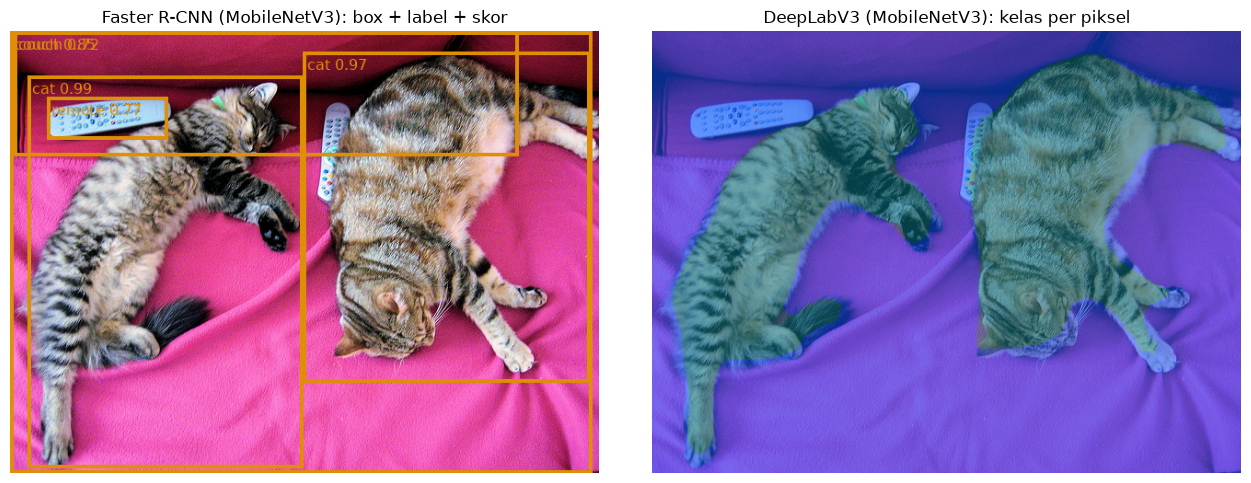

In [13]:
if UNDUH_PRETRAINED:
    bobot_seg = models.segmentation.DeepLabV3_MobileNet_V3_Large_Weights.COCO_WITH_VOC_LABELS_V1
    segmentor = models.segmentation.deeplabv3_mobilenet_v3_large(weights=bobot_seg, progress=False).eval()
    x_seg = bobot_seg.transforms()(foto).unsqueeze(0)
    with torch.no_grad():
        skor_piksel = segmentor(x_seg)['out'][0]             # (21, h, w)
    print(f"Output segmentasi: {tuple(skor_piksel.shape)} = (kelas, tinggi, lebar)")

    peta = F.interpolate(skor_piksel[None], size=foto.size[::-1], mode='bilinear')[0].argmax(0)
    kelas_seg = bobot_seg.meta['categories']
    ada = [k for k in peta.unique().tolist() if k != 0]
    print("Kelas terdeteksi per piksel:", {kelas_seg[k]: f"{(peta == k).float().mean():.1%}" for k in ada})

    gambar_det = draw_bounding_boxes(foto_tensor, keluaran['boxes'][yakin],
                                     labels=[f"{nama_kelas[l]} {s:.2f}" for l, s in zip(keluaran['labels'][yakin], keluaran['scores'][yakin])],
                                     colors=ORANGE, width=4, font=font_manager.findfont('DejaVu Sans'), font_size=16)
    topeng = torch.stack([peta == k for k in ada]) if ada else torch.zeros(1, *peta.shape, dtype=torch.bool)
    gambar_seg = draw_segmentation_masks(foto_tensor, topeng, alpha=0.55, colors=[TEAL, BLUE, ORANGE][:len(topeng)])

    fig, axs = plt.subplots(1, 2, figsize=(13, 4.8))
    axs[0].imshow(gambar_det.permute(1, 2, 0)); axs[0].set_title('Faster R-CNN (MobileNetV3): box + label + skor')
    axs[1].imshow(gambar_seg.permute(1, 2, 0)); axs[1].set_title('DeepLabV3 (MobileNetV3): kelas per piksel')
    for ax in axs:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

Perhatikan perbedaan output keduanya: detektor memberi **box per objek** (dua kucing terpisah), sedangkan segmentasi semantik memberi **kelas per piksel** tanpa membedakan kucing #1 dan #2. Membedakan instans per piksel adalah tugas *instance segmentation* (Mask R-CNN, slide 52).

---

## 9. Mini U-Net: Encoder–Decoder dengan *Skip Concatenation* (Slide 51)

Kita latih U-Net kecil pada data sintetis: citra $64\times64$ berisi **lingkaran** (target) dan **persegi** (pengecoh). Tugasnya memprediksi *mask* lingkaran per piksel. Untuk melihat peran *skip connection*, kita latih dua versi: **dengan** dan **tanpa** skip.

In [14]:
def buat_batch(n, ukuran=64, rng=np.random.default_rng()):
    x = np.zeros((n, 3, ukuran, ukuran), dtype=np.float32)
    y = np.zeros((n, 1, ukuran, ukuran), dtype=np.float32)
    yy, xx = np.mgrid[:ukuran, :ukuran]
    for i in range(n):
        x[i] = rng.uniform(0, 0.3, (3, 1, 1)) + rng.normal(0, 0.08, (3, ukuran, ukuran))
        for _ in range(rng.integers(1, 4)):                          # lingkaran = target
            cx, cy, r = rng.uniform(10, 54), rng.uniform(10, 54), rng.uniform(5, 12)
            m = (xx - cx) ** 2 + (yy - cy) ** 2 <= r ** 2
            x[i][:, m] = rng.uniform(0.5, 1.0, (3, 1))
            y[i, 0][m] = 1
        for _ in range(rng.integers(0, 3)):                          # persegi = pengecoh
            cx, cy, r = rng.uniform(8, 56), rng.uniform(8, 56), rng.uniform(4, 10)
            m = (np.abs(xx - cx) <= r) & (np.abs(yy - cy) <= r)
            x[i][:, m] = rng.uniform(0.5, 1.0, (3, 1))
            y[i, 0][m] = 0
    return torch.from_numpy(x), torch.from_numpy(y)


def conv_blok(c_in, c_out):
    return nn.Sequential(nn.Conv2d(c_in, c_out, 3, padding=1), nn.BatchNorm2d(c_out), nn.ReLU(inplace=True),
                         nn.Conv2d(c_out, c_out, 3, padding=1), nn.BatchNorm2d(c_out), nn.ReLU(inplace=True))


class MiniUNet(nn.Module):
    def __init__(self, skip=True):
        super().__init__()
        self.skip = skip
        self.enc1, self.enc2 = conv_blok(3, 16), conv_blok(16, 32)
        self.bottleneck = conv_blok(32, 64)
        self.up2 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec2 = conv_blok(64 if skip else 32, 32)
        self.up1 = nn.ConvTranspose2d(32, 16, 2, stride=2)
        self.dec1 = conv_blok(32 if skip else 16, 16)
        self.head = nn.Conv2d(16, 1, 1)

    def forward(self, x, verbose=False):
        e1 = self.enc1(x)                         # (16, 64, 64)
        e2 = self.enc2(F.max_pool2d(e1, 2))       # (32, 32, 32)
        b = self.bottleneck(F.max_pool2d(e2, 2))  # (64, 16, 16)
        d2 = self.up2(b)                          # (32, 32, 32)
        if self.skip:
            d2 = torch.cat([d2, e2], dim=1)       # skip concatenation -> (64, 32, 32)
        d2 = self.dec2(d2)
        d1 = self.up1(d2)                         # (16, 64, 64)
        if self.skip:
            d1 = torch.cat([d1, e1], dim=1)       # -> (32, 64, 64)
        d1 = self.dec1(d1)
        if verbose:
            for nama, t in [('enc1', e1), ('enc2', e2), ('bottleneck', b), ('dec2', d2), ('dec1', d1)]:
                print(f"  {nama:<11}{tuple(t.shape[1:])}")
        return self.head(d1)


print("Aliran shape MiniUNet (dengan skip):")
out = MiniUNet()(torch.randn(1, 3, 64, 64), verbose=True)
print(f"  output     {tuple(out.shape[1:])}  <- 1 logit per piksel, resolusi sama dengan input")

Aliran shape MiniUNet (dengan skip):
  enc1       (16, 64, 64)
  enc2       (32, 32, 32)
  bottleneck (64, 16, 16)
  dec2       (32, 32, 32)
  dec1       (16, 64, 64)
  output     (1, 64, 64)  <- 1 logit per piksel, resolusi sama dengan input


In [15]:
LANGKAH = 300 if MODE_CEPAT else 1500
rng_uji = np.random.default_rng(123)
x_uji, y_uji = buat_batch(128, rng=rng_uji)


def iou_mask(logit, y):
    pred = logit > 0
    irisan = (pred & (y > 0.5)).sum().item()
    gabungan = (pred | (y > 0.5)).sum().item()
    return irisan / max(gabungan, 1)


model_unet = {}
for skip in [True, False]:
    torch.manual_seed(0)
    m = MiniUNet(skip).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=3e-3)
    rng_latih = np.random.default_rng(0)
    t0 = time.time()
    m.train()
    for langkah in range(LANGKAH):
        x, y = buat_batch(32, rng=rng_latih)
        x, y = x.to(device), y.to(device)
        opt.zero_grad()
        loss = F.binary_cross_entropy_with_logits(m(x), y)
        loss.backward()
        opt.step()
    m.eval()
    with torch.no_grad():
        logit_uji = m(x_uji.to(device)).cpu()
    model_unet[skip] = (m, logit_uji)
    print(f"{'Dengan' if skip else 'Tanpa '} skip: {sum(p.numel() for p in m.parameters()):,} parameter | "
          f"loss akhir {loss.item():.3f} | IoU uji {iou_mask(logit_uji, y_uji):.3f} | {time.time()-t0:.0f} s")

Dengan skip: 117,681 parameter | loss akhir 0.016 | IoU uji 0.969 | 14 s


Tanpa  skip: 106,161 parameter | loss akhir 0.028 | IoU uji 0.950 | 12 s


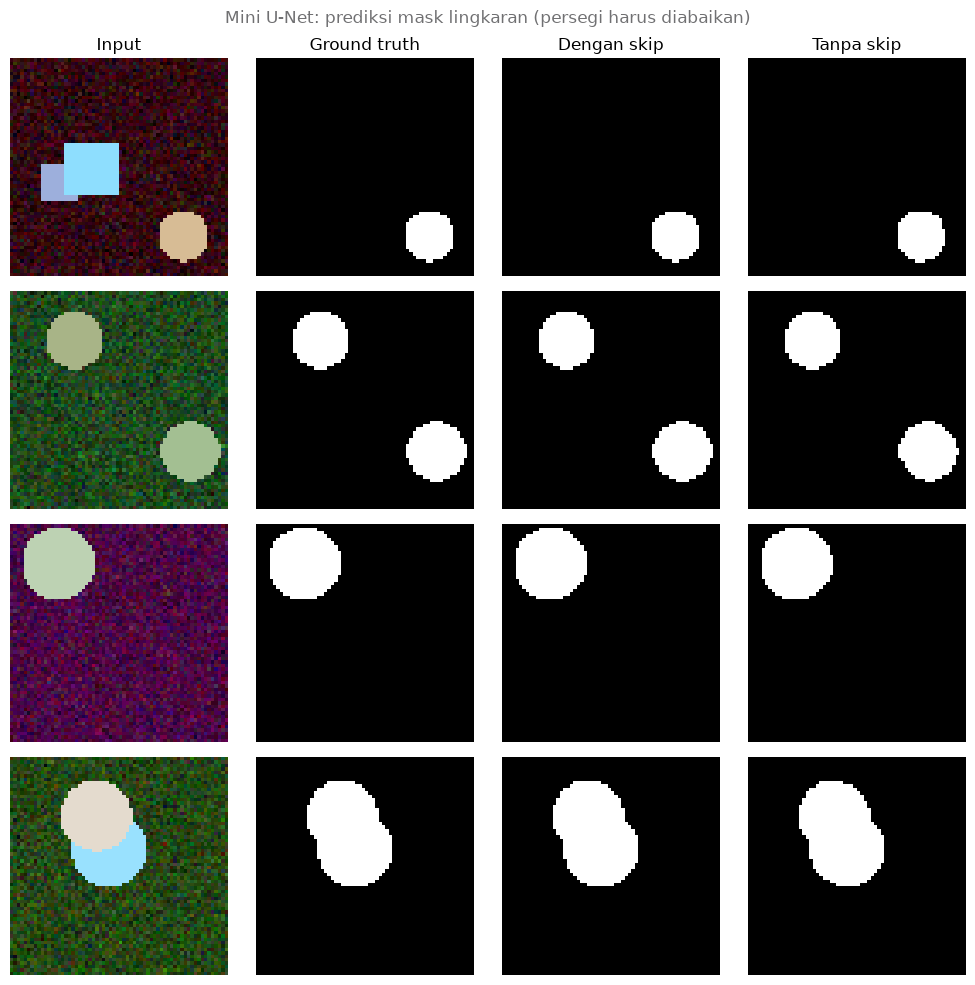

In [16]:
fig, axs = plt.subplots(4, 4, figsize=(10, 10))
for baris, i in enumerate([0, 1, 2, 3]):
    panel = [(x_uji[i].permute(1, 2, 0).clamp(0, 1), 'Input'), (y_uji[i, 0], 'Ground truth'),
             ((model_unet[True][1][i, 0] > 0).float(), 'Dengan skip'), ((model_unet[False][1][i, 0] > 0).float(), 'Tanpa skip')]
    for kolom, (gambar, judul) in enumerate(panel):
        axs[baris, kolom].imshow(gambar, cmap='gray' if kolom else None)
        axs[baris, kolom].axis('off')
        if baris == 0:
            axs[baris, kolom].set_title(judul)
plt.suptitle('Mini U-Net: prediksi mask lingkaran (persegi harus diabaikan)', color=MUTE)
plt.tight_layout()
plt.show()

**Interpretasi:** tanpa skip, decoder hanya menerima fitur beresolusi rendah dari *bottleneck* ($16\times16$) dan harus "menebak" kembali detail batas objek saat upsampling. *Skip concatenation* mengirim fitur resolusi tinggi dari encoder langsung ke decoder, sehingga IoU lebih tinggi. Pada data sintetis yang sederhana ini selisihnya kecil dan terutama tampak di **tepi** lingkaran. Selisih akan membesar untuk objek kecil dan batas yang rumit, seperti pada citra medis (lihat Tugas 5).

---

## 10. Ringkasan & Tugas Terstruktur (TT 3×60′)

### Ringkasan Eksperimen:
1. **Format box:** VOC `xyxy`, COCO `xywh`, dan YOLO `cxcywh` relatif hanyalah parameterisasi berbeda dari box yang sama. Salah membaca format menurunkan IoU box sempurna menjadi 0,5.
2. **Resize:** label piksel (VOC/COCO) wajib diskalakan, label YOLO tidak.
3. **IoU, NMS, mAP** versi sendiri identik dengan `torchvision.ops`. mAP@[.5:.95] jauh lebih ketat daripada mAP@0.5 karena ikut menilai presisi lokalisasi.
4. **YOLO** mengubah deteksi menjadi regresi pada tensor $7\times7\times30$; sel yang memuat pusat objek bertanggung jawab.
5. **Satu backbone, banyak head:** MobileNetV3 dipakai untuk deteksi (Faster R-CNN) dan segmentasi (DeepLabV3). Pada U-Net, *skip concatenation* menajamkan batas mask.

---

### Soal Tugas Terstruktur:
1. **Tugas 1 — Verifikasi Latihan Slide:** gunakan `iou_matriks`, `voc_ke_coco`, dan `voc_ke_yolo` untuk memeriksa jawaban tangan Anda atas Latihan Mandiri no. 4 (slide 54): IoU box $(10,20,50,80)$ dan $(30,40,70,90)$, serta penulisan prediksi dalam format COCO dan YOLO pada citra $100\times100$.
2. **Tugas 2 — NMS Per Kelas:** modifikasi `nms_manual` agar hanya menekan box **dengan kelas yang sama** (bandingkan dengan `torchvision.ops.batched_nms`). Mengapa NMS lintas kelas berbahaya untuk kucing yang duduk di atas sofa?
3. **Tugas 3 — Sensitivitas mAP:** ubah rentang `derau` pada Bagian 6 menjadi `(0.01, 0.10)` lalu `(0.10, 0.40)`. Bagaimana mAP@0.5 dan mAP@[.5:.95] berubah? Jelaskan mengapa selisih keduanya melebar.
4. **Tugas 4 — Instance Segmentation:** jalankan `models.detection.maskrcnn_resnet50_fpn` (bobot `COCO_V1`) pada citra yang sama. Tunjukkan bahwa kedua kucing kini mendapat mask terpisah, dan tuliskan bentuk tensor `masks` pada output.
5. **Tugas 5 — Objek Kecil:** ubah jari-jari lingkaran di `buat_batch` menjadi `rng.uniform(2, 5)` dan latih ulang kedua versi MiniUNet. Bagaimana selisih IoU dengan vs tanpa skip berubah? Mengapa?